## Data Insights & Analysis Summary

### Exploratory Findings
- **Loan Intent:** The highest volume of applications are for Education, followed closely by Medical and Venture purposes.
- **Home Ownership:** A large share of applicants Rent or have a Mortgage — these groups make up most of the applicant pool.
- **Education Levels:** Applicants span a wide range of education levels, encoded to test whether it relates to repayment reliability.

### What Actually Predicts Default (Feature Importance)
The Random Forest model relied most heavily on:
1. **Previous loan defaults on file** (23% importance) — by far the strongest signal
2. **Loan percent of income** (16%) — how much of the applicant's income the loan represents
3. **Loan interest rate** (15%) — often already reflects lender-assessed risk
4. **Person income** (13%)
5. **Loan amount** (6%)
6. **Credit score** (5%)

**Notable finding:** credit score, while relevant, was *not* the dominant factor — prior default history and debt-to-income ratio mattered more. This runs against the common assumption that credit score is the primary driver of lending risk.

### Model Performance
Two models were trained and compared: **Random Forest** and **XGBoost**.

At default thresholds (0.5), Random Forest reached 93% accuracy and 0.973 ROC-AUC, while XGBoost reached 91% accuracy and a slightly higher 0.978 ROC-AUC. The near-identical AUC scores show both models are almost equally good at *ranking* applicants by risk — the real difference lies in where each model's default threshold happens to sit.

### The Class Imbalance Investigation
The dataset is imbalanced (~78% non-default, ~22% default). We tested three ways to improve recall on defaults (the harder, and more costly, class to miss):

1. **`class_weight='balanced'`** — barely moved recall (0.75 → 0.74). A grid search across weight ratios (1x to 10x) confirmed this: recall actually *declined slightly* as weight increased, likely because heavier weighting causes individual trees to overfit to minority-class noise, which doesn't help the ensemble vote.
2. **Threshold tuning** — this was the real lever. Lowering Random Forest's threshold from 0.5 to 0.35 raised recall from 0.75 to 0.85, with precision dropping from 0.90 to 0.80 in exchange.
3. **Switching to XGBoost** with `scale_pos_weight` — recall reached 0.92 at XGBoost's default threshold, but at the cost of precision dropping to 0.74.

### Fair Model Comparison
Comparing both models at the *same* recall target (85%) — rather than their default thresholds — gives the fairest picture:

| Model | Threshold | Recall | Precision |
|---|---|---|---|
| Random Forest | 0.35 | 0.851 | 0.803 |
| XGBoost | 0.63 | 0.850 | 0.826 |

**XGBoost wins on precision at equal recall** (0.826 vs 0.803), a modest but consistent edge.

### Conclusion & Recommendation
- **XGBoost is the stronger model**, but the improvement over Random Forest is incremental, not dramatic.
- **Threshold tuning matters more than model choice.** Moving Random Forest's threshold from 0.5 to 0.35 improved recall by 10 points — a bigger swing than switching algorithms entirely.
- **Recommended approach:** use XGBoost with a threshold tuned to the business's actual cost tradeoff — how expensive is a missed default versus a wrongly rejected good borrower. That threshold decision should be made by the business, not defaulted to 0.5.
- **Class weighting alone is not an effective lever for Random Forest** on this dataset — it should not be relied on in isolation to fix imbalance-driven recall issues.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#!git clone https://github.com/ayushdhasmana/Loan-Risk-Analysis.git
#%cd Loan-Risk-Analysis

fatal: destination path 'Loan-Risk-Analysis' already exists and is not an empty directory.
/content/Loan-Risk-Analysis


In [2]:
df = pd.read_csv("data/loan_data_raw.csv")

In [3]:
# This counts exactly identical rows
df.duplicated().sum()

np.int64(0)

In [4]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [5]:
df['person_education'].unique()

array(['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate'],
      dtype=object)

In [6]:
df['person_home_ownership'].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [7]:
df['loan_intent'].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [8]:
# 1. Create a cleaned copy for age and experience
df_clean = df[(df['person_age'] < 100) & (df['person_emp_exp'] < 60)]

# 2. Print how many rows were removed
print(f"Rows removed: {len(df) - len(df_clean)}")

# 3. Update the main dataframe
df = df_clean

Rows removed: 10


In [9]:
df['loan_status'].value_counts()

,count
loan_status,
0,34990
1,10000


In [10]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,44990.000000,4.499000e+04,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000
mean,27.744543,7.990883e+04,5.390465,9583.297888,11.006510,0.139737,5.865259,632.578329,0.222272
std,5.890563,6.332359e+04,5.906165,6314.982527,2.979037,0.087208,3.874023,50.394327,0.415777
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.719575e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704550e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.577700e+04,8.000000,12237.750000,12.990000,0.190000,8.000000,670.000000,0.000000
max,78.000000,2.448661e+06,58.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


In [11]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


/tmp/ipykernel_25575/1595878347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='loan_intent', order=df['loan_intent'].value_counts().index, palette='viridis')


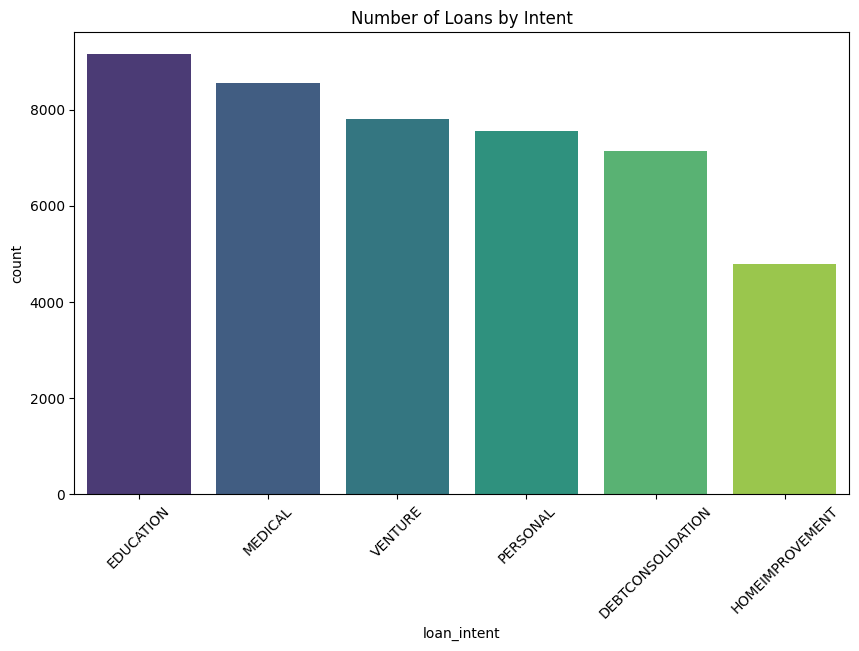

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='loan_intent', order=df['loan_intent'].value_counts().index, palette='viridis')
plt.title('Number of Loans by Intent')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_25575/358353074.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='person_home_ownership', order=df['person_home_ownership'].value_counts().index, palette='viridis')


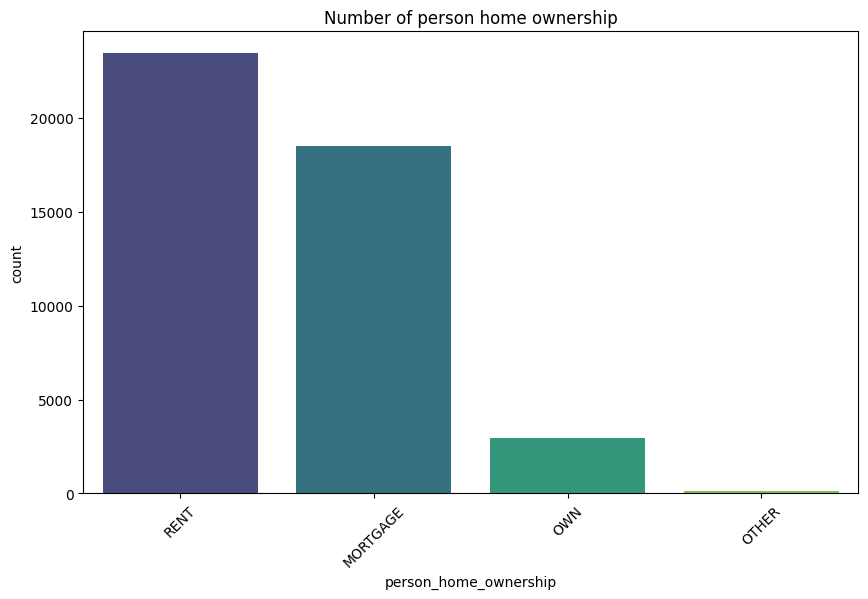

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='person_home_ownership', order=df['person_home_ownership'].value_counts().index, palette='viridis')
plt.title('Number of person home ownership')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_25575/3512284799.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='person_education', order=df['person_education'].value_counts().index, palette='viridis')


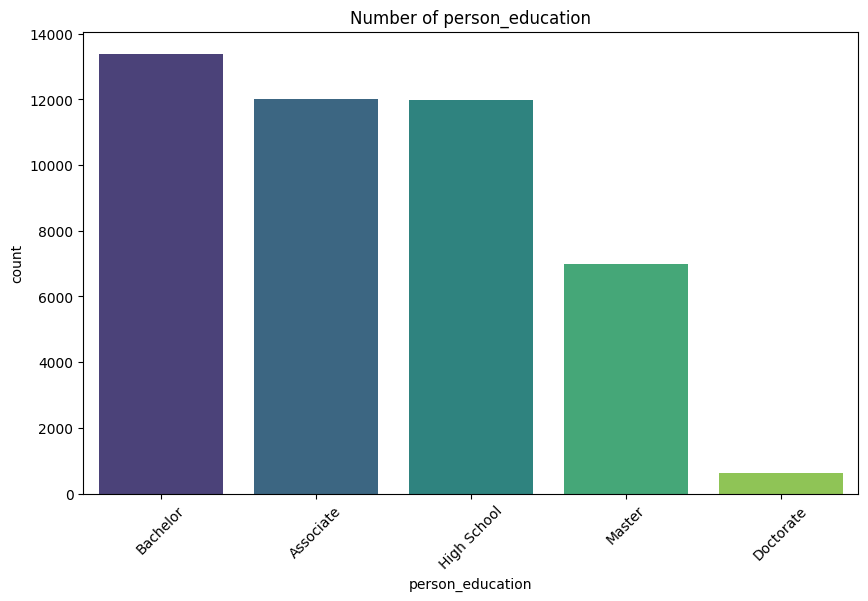

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='person_education', order=df['person_education'].value_counts().index, palette='viridis')
plt.title('Number of person_education')
plt.xticks(rotation=45)
plt.show()

In [15]:
# Select the categorical columns you want to encode
cols_to_encode = ['person_education', 'person_home_ownership', 'loan_intent', 'person_gender', 'previous_loan_defaults_on_file']

# drop_first=True helps avoid the "dummy variable trap" (multicollinearity)
df1 = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

# Preview the new columns
df1.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_education_Bachelor,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_gender_male,previous_loan_defaults_on_file_Yes
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,False,...,False,False,True,False,False,False,True,False,False,False
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,False,...,False,True,False,True,False,False,False,False,False,True
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,False,...,False,False,False,False,False,True,False,False,False,False
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,True,...,False,False,True,False,False,True,False,False,False,False
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,False,...,False,False,True,False,False,True,False,False,True,False


In [16]:
df1

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_education_Bachelor,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_gender_male,previous_loan_defaults_on_file_Yes
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,False,...,False,False,True,False,False,False,True,False,False,False
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,False,...,False,True,False,True,False,False,False,False,False,True
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,False,...,False,False,False,False,False,True,False,False,False,False
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,True,...,False,False,True,False,False,True,False,False,False,False
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,False,...,False,False,True,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,47971.0,6,15000.0,15.66,0.31,3.0,645,1,False,...,False,False,True,False,False,True,False,False,True,False
44996,37.0,65800.0,17,9000.0,14.07,0.14,11.0,621,1,False,...,False,False,True,False,True,False,False,False,False,False
44997,33.0,56942.0,7,2771.0,10.02,0.05,10.0,668,1,False,...,False,False,True,False,False,False,False,False,True,False
44998,29.0,33164.0,4,12000.0,13.23,0.36,6.0,604,1,True,...,False,False,True,True,False,False,False,False,True,False


In [17]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
X = df1.drop('loan_status', axis=1)
y = df1['loan_status']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 35992
Testing set size: 8998


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      6999
           1       0.90      0.75      0.82      1999

    accuracy                           0.93      8998
   macro avg       0.92      0.86      0.89      8998
weighted avg       0.93      0.93      0.92      8998



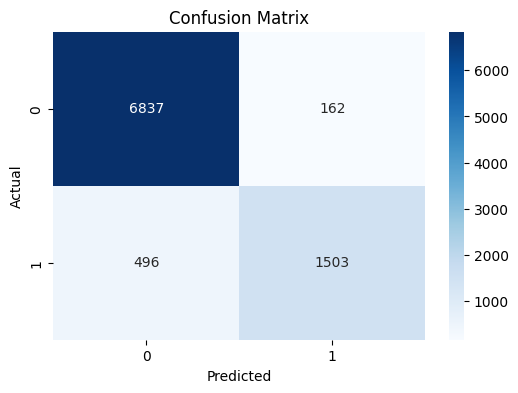

In [19]:
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Visualize the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [20]:
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

# Get probability predictions (needed for AUC and Log Loss)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate Metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
loss = log_loss(y_test, y_prob)

print(f"Accuracy Score: {acc:.4f}")
print(f"ROC-AUC Score:  {auc:.4f}")
print(f"Log Loss:       {loss:.4f}")

Accuracy Score: 0.9269
ROC-AUC Score:  0.9729
Log Loss:       0.1737


In [21]:
# Optional experiment to see "True" predictive power without interest rates
X_no_rate = X.drop('loan_int_rate', axis=1)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_no_rate, y, test_size=0.2, random_state=42)

model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train2, y_train2)
print(f"AUC without Interest Rate: {roc_auc_score(y_test2, model2.predict_proba(X_test2)[:, 1]):.4f}")

AUC without Interest Rate: 0.9523


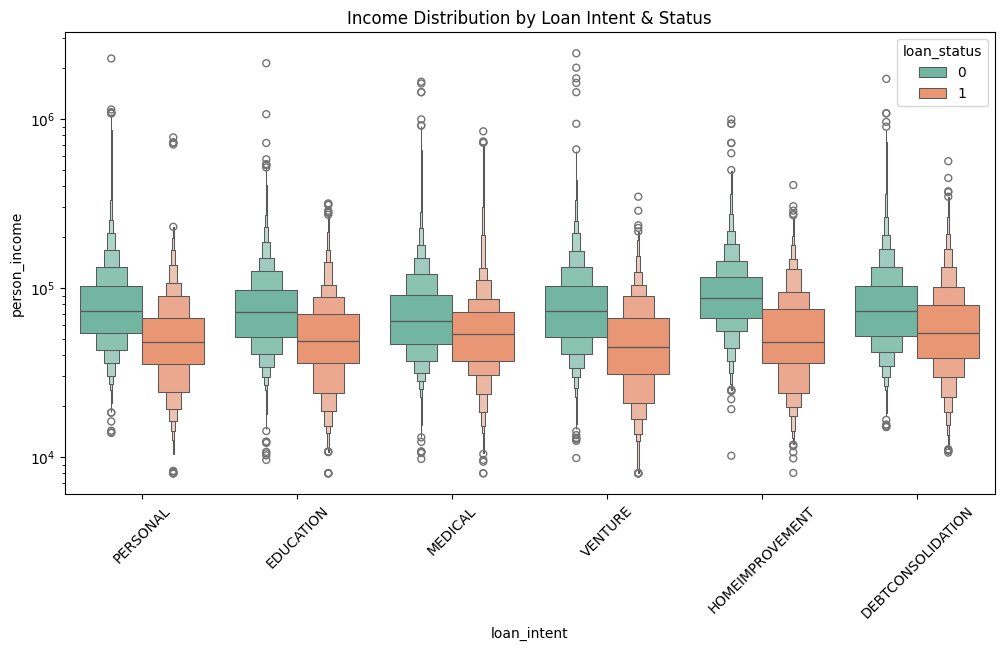

In [22]:
plt.figure(figsize=(12, 6))
sns.boxenplot(data=df_clean, x='loan_intent', y='person_income', hue='loan_status', palette='Set2')
plt.yscale('log') # Using log scale because income has a wide range
plt.title('Income Distribution by Loan Intent & Status')
plt.xticks(rotation=45)
plt.show()

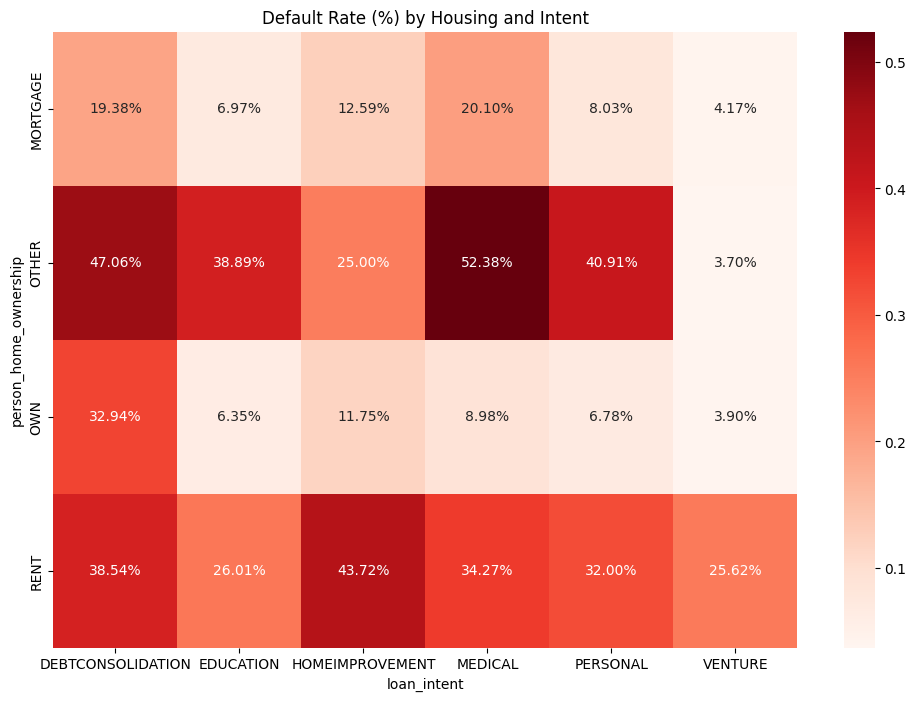

In [23]:
# Create a pivot table of default rates
pivot_df = df_clean.pivot_table(index='person_home_ownership',
                                columns='loan_intent',
                                values='loan_status',
                                aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, cmap='Reds', fmt='.2%')
plt.title('Default Rate (%) by Housing and Intent')
plt.show()

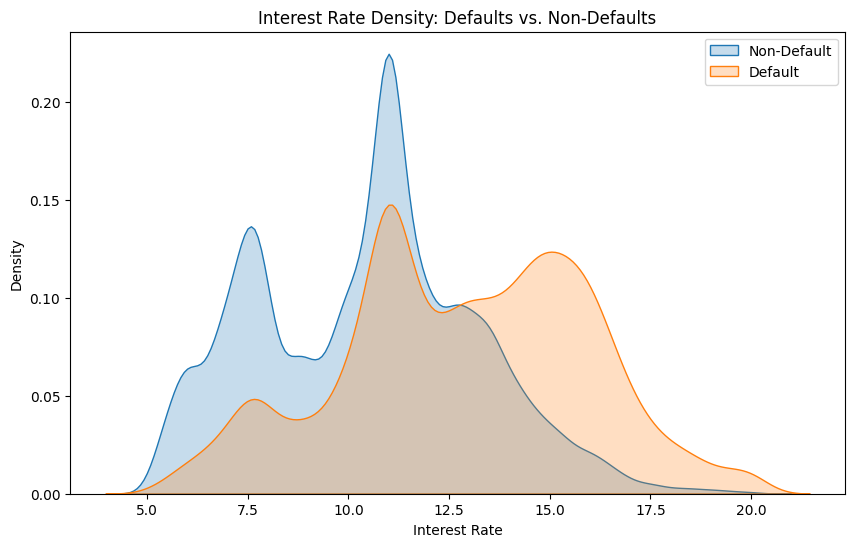

In [24]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_clean[df_clean['loan_status'] == 0]['loan_int_rate'], label='Non-Default', fill=True)
sns.kdeplot(df_clean[df_clean['loan_status'] == 1]['loan_int_rate'], label='Default', fill=True)
plt.title('Interest Rate Density: Defaults vs. Non-Defaults')
plt.xlabel('Interest Rate')
plt.legend()
plt.show()

In [25]:
# Compare with class_weight='balanced' to address class imbalance
model_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)
y_prob_balanced = model_balanced.predict_proba(X_test)[:, 1]

print("--- Classification Report (class_weight='balanced') ---")
print(classification_report(y_test, y_pred_balanced))

print(f"ROC-AUC Score (balanced): {roc_auc_score(y_test, y_prob_balanced):.4f}")

--- Classification Report (class_weight='balanced') ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      6999
           1       0.91      0.74      0.82      1999

    accuracy                           0.93      8998
   macro avg       0.92      0.86      0.89      8998
weighted avg       0.93      0.93      0.92      8998

ROC-AUC Score (balanced): 0.9735


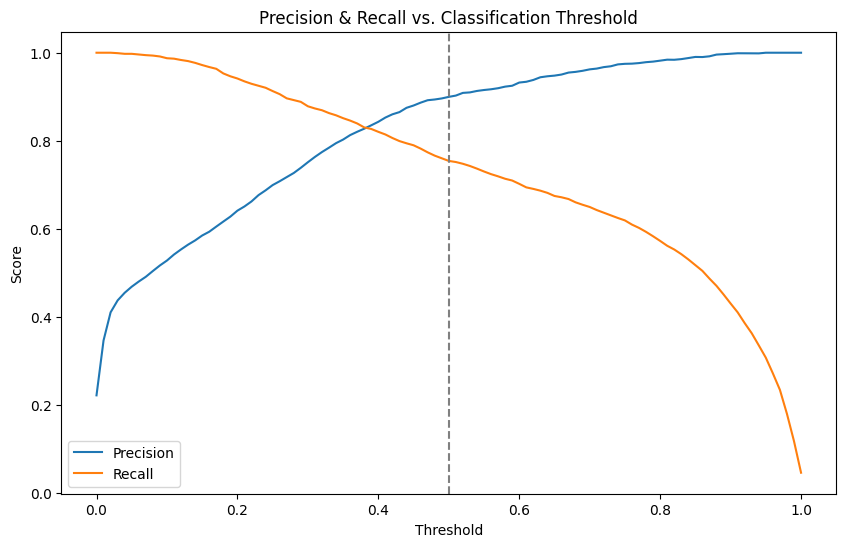

--- Classification Report (threshold = 0.3) ---
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      6999
           1       0.75      0.88      0.81      1999

    accuracy                           0.91      8998
   macro avg       0.86      0.90      0.87      8998
weighted avg       0.92      0.91      0.91      8998



In [26]:
from sklearn.metrics import precision_recall_curve, f1_score

# Get precision, recall, and thresholds from the original model's probabilities
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Plot precision and recall vs threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs. Classification Threshold')
plt.legend()
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.show()

# Try a lower threshold, e.g. 0.3, to boost recall on defaults
custom_threshold = 0.3
y_pred_custom = (y_prob >= custom_threshold).astype(int)

print(f"--- Classification Report (threshold = {custom_threshold}) ---")
print(classification_report(y_test, y_pred_custom))

In [27]:
try:
    import xgboost
    print("xgboost is installed, version:", xgboost.__version__)
except ImportError:
    print("Not installed — run: !pip install xgboost")

xgboost is installed, version: 3.3.0


In [28]:
from xgboost import XGBClassifier

# scale_pos_weight helps XGBoost handle class imbalance (similar idea to class_weight='balanced')
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("--- Classification Report (XGBoost) ---")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score (XGBoost): {roc_auc_score(y_test, y_prob_xgb):.4f}")

--- Classification Report (XGBoost) ---
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      6999
           1       0.74      0.92      0.82      1999

    accuracy                           0.91      8998
   macro avg       0.86      0.91      0.88      8998
weighted avg       0.92      0.91      0.91      8998

ROC-AUC Score (XGBoost): 0.9775


In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'class_weight': [{0: 1, 1: w} for w in [1, 2, 3, 5, 8, 10]]
}

grid_search = GridSearchCV(
    RandomForestClassifier(n_estimators=100, random_state=42),
    param_grid,
    scoring='recall',  # optimizing directly for recall on class 1
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best class_weight:", grid_search.best_params_)
print("Best CV recall:", grid_search.best_score_)

Best class_weight: {'class_weight': {0: 1, 1: 1}}
Best CV recall: 0.7650277170518425


In [30]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results[['param_class_weight', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False)

,param_class_weight,mean_test_score,std_test_score
0,"{0: 1, 1: 1}",0.765028,0.010902
1,"{0: 1, 1: 2}",0.761403,0.009834
2,"{0: 1, 1: 3}",0.759528,0.011836
3,"{0: 1, 1: 5}",0.754528,0.013313
5,"{0: 1, 1: 10}",0.749404,0.014078
4,"{0: 1, 1: 8}",0.748654,0.014001


/tmp/ipykernel_25575/981959479.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


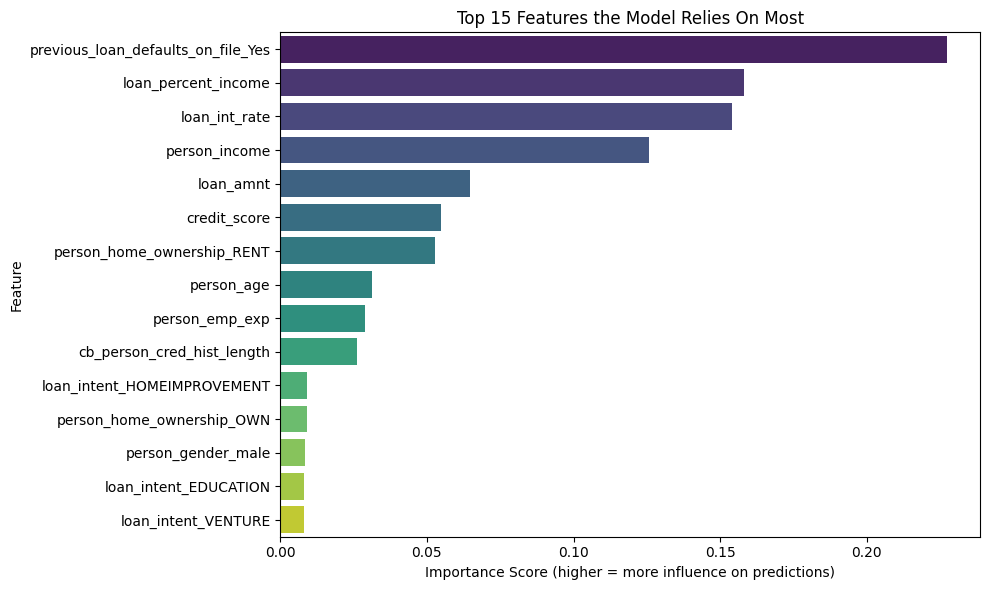

Top 15 Features by Importance:
previous_loan_defaults_on_file_Yes    0.227246
loan_percent_income                   0.158237
loan_int_rate                         0.154015
person_income                         0.125616
loan_amnt                             0.064800
credit_score                          0.054796
person_home_ownership_RENT            0.052779
person_age                            0.031260
person_emp_exp                        0.028786
cb_person_cred_hist_length            0.026226
loan_intent_HOMEIMPROVEMENT           0.009260
person_home_ownership_OWN             0.009159
person_gender_male                    0.008319
loan_intent_EDUCATION                 0.008148
loan_intent_VENTURE                   0.008011
dtype: float64


In [31]:
# ============================================
# FEATURE IMPORTANCE — Random Forest
# ============================================
# Goal: find out which columns the model relied on most
# when deciding if someone will default or not.
# RandomForestClassifier automatically tracks this while training,
# we just need to pull it out and sort it.

# Step 1: Pair up each feature name with its importance score
# (model.feature_importances_ is just a list of numbers in the
# same order as the columns in X_train)
feature_importance = pd.Series(
    model.feature_importances_,   # the importance scores
    index=X_train.columns         # the matching column names
)

# Step 2: Sort so the most important features come first,
# and keep only the top 15 (the rest are usually negligible)
top_features = feature_importance.sort_values(ascending=False).head(15)

# Step 3: Plot it as a horizontal bar chart
# (horizontal is easier to read when feature names are long)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 15 Features the Model Relies On Most')
plt.xlabel('Importance Score (higher = more influence on predictions)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Step 4: Also print it as a plain table, useful for the write-up
print("Top 15 Features by Importance:")
print(top_features)

In [32]:
# ============================================
# FAIR COMPARISON — Random Forest vs XGBoost
# ============================================
# Problem: earlier we compared RF and XGBoost at their DEFAULT
# thresholds (0.5), but XGBoost's scale_pos_weight pushed it to
# a different operating point than RF. That's not a fair fight —
# it's like comparing a sprinter's max speed to a marathoner's
# average pace.
#
# Fix: pick ONE recall target (e.g. 85%) and find the threshold
# EACH model needs to hit that same recall. Then compare precision
# at that shared recall — that tells us which model is actually
# better, not just which one is set more aggressively.

from sklearn.metrics import precision_recall_curve

def find_threshold_for_recall(y_true, y_prob, target_recall=0.85):
    """
    Given true labels and predicted probabilities, find the
    threshold that gets us closest to our target recall.
    Returns: the threshold, and the actual recall/precision at it.
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    # precision_recall_curve gives us one extra point at the end
    # with no matching threshold, so we drop it to keep arrays aligned
    precisions = precisions[:-1]
    recalls = recalls[:-1]

    # Find the index where recall is closest to our target
    # (recall generally decreases as threshold increases, so we
    # look for the point nearest to what we want)
    idx = (abs(recalls - target_recall)).argmin()

    return thresholds[idx], recalls[idx], precisions[idx]

# --- Runing this for Random Forest ---
rf_threshold, rf_recall, rf_precision = find_threshold_for_recall(
    y_test, y_prob, target_recall=0.85
)

# --- Runing this for XGBoost ---
xgb_threshold, xgb_recall, xgb_precision = find_threshold_for_recall(
    y_test, y_prob_xgb, target_recall=0.85
)

# --- Print a side-by-side summary ---
print("=== Fair Comparison at ~85% Recall ===\n")

print("Random Forest:")
print(f"  Threshold needed: {rf_threshold:.3f}")
print(f"  Recall achieved:  {rf_recall:.3f}")
print(f"  Precision at that recall: {rf_precision:.3f}\n")

print("XGBoost:")
print(f"  Threshold needed: {xgb_threshold:.3f}")
print(f"  Recall achieved:  {xgb_recall:.3f}")
print(f"  Precision at that recall: {xgb_precision:.3f}")

=== Fair Comparison at ~85% Recall ===

Random Forest:
  Threshold needed: 0.350
  Recall achieved:  0.851
  Precision at that recall: 0.803

XGBoost:
  Threshold needed: 0.630
  Recall achieved:  0.850
  Precision at that recall: 0.826
